In [1]:
import sctour as sct
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
adata0 = sc.read('01.Data/Nodule_section2_new_anno/Processed_Nodule.h5ad')
adata0.shape

color_map = {'Early_nodule_cortex':'#a6d96a', 'Infected_Zone':'#f8766d', 'Meristems':'#336699', 'Vascular_tissue':'#fdb863','Peripheral_tissues':'#9970ab'}

In [27]:
import matplotlib.colors as mcolors

monocle2_pseudotime_cmap = mcolors.LinearSegmentedColormap.from_list(
    "monocle2_pseudotime",
    ["#132B43", "#56B1F7"]
)

In [3]:
adata = adata0.copy()
adata2 = adata0.copy()

# Top 1,000 genes (by default)
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=1000, subset=True) # 1,000
# Top 2,000 genes
sc.pp.calculate_qc_metrics(adata2, percent_top=None, log1p=False, inplace=True)
sc.pp.highly_variable_genes(adata2, flavor='seurat_v3', n_top_genes=2000, subset=True)
adata.obs.head()

,orig.ident,nCount_RNA,nFeature_RNA,x,y,sample_id,RNA_snn_res.0.6,seurat_clusters,linemut_celltype,RNA_snn_res.0.4,...,crop_cluster,sublineage_annotation,sublineage_annotation_refined,final_sublineage_annotation,Spatial_row,Spatial_col,Spatial_imagerow,Spatial_imagecol,n_genes_by_counts,total_counts
17700_21000,Lj_6dai_bin50,2760.0,1558,17700,21000,SS200000124TR_B6_6dai_sec1,8,2,Early_pre_infection_thread_cell,0,...,2,NA,NA,Infected_Zone,17700,21000,17700,21000,1558,2760.0
17750_21300,Lj_6dai_bin50,2906.0,1645,17750,21300,SS200000124TR_B6_6dai_sec1,0,2,Vascular_cell,0,...,2,NA,NA,Infected_Zone,17750,21300,17750,21300,1645,2906.0
17800_21250,Lj_6dai_bin50,2487.0,1392,17800,21250,SS200000124TR_B6_6dai_sec1,5,4,Nitrogen_fixing_bacteroid_zone_cell,2,...,4,NA,NA,Infected_Zone,17800,21250,17800,21250,1392,2487.0
17850_21300,Lj_6dai_bin50,2505.0,1433,17850,21300,SS200000124TR_B6_6dai_sec1,5,2,Nitrogen_fixing_bacteroid_zone_cell,0,...,2,NA,NA,Infected_Zone,17850,21300,17850,21300,1433,2505.0
17900_20650,Lj_6dai_bin50,1639.0,1051,17900,20650,SS200000124TR_B6_6dai_sec1,2,3,Ground_Dermal_cell,0,...,3,NA,NA,Meristems,17900,20650,17900,20650,1051,1639.0


In [4]:
adata.X=adata.X.astype(np.float32)

tnode = sct.train.Trainer(adata)
tnode.train()

adata.obs['ptime'] = tnode.get_time()

mix_zs, zs, pred_zs = tnode.get_latentsp()
adata.obsm['X_TNODE'] = mix_zs
adata.obsm['X_VF'] = tnode.get_vector_field(adata.obs['ptime'].values, adata.obsm['X_TNODE'])

adata = adata[np.argsort(adata.obs['ptime'].values), :].copy()

sc.pp.neighbors(adata, use_rep='X_TNODE', n_neighbors=15)
sc.tl.umap(adata, min_dist=0.1)

adata.obs['ptime_reverse'] = sct.train.reverse_time(adata.obs['ptime'].values) # use this to reverse pseudotime

Running using CPU.
Epoch 400: 100%|██████████| 400/400 [02:47<00:00,  2.39epoch/s, train_loss=168, val_loss=175]
/home/chenr/miniconda3/envs/sctour2/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


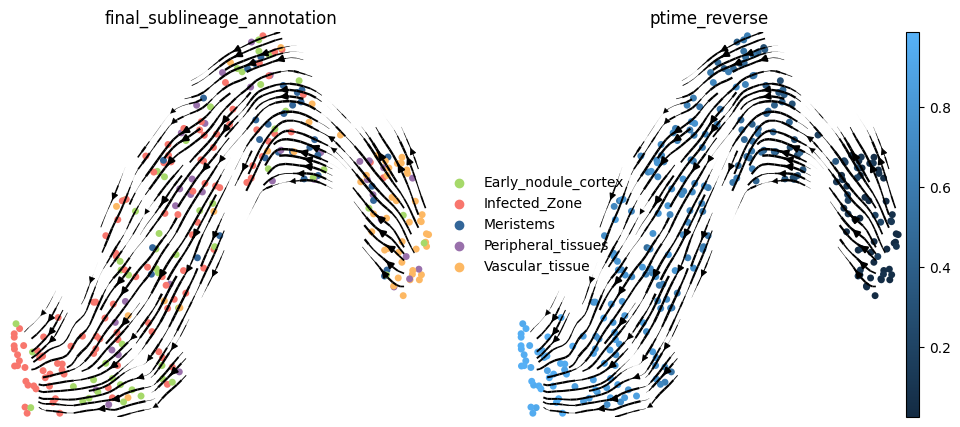

In [34]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 5))
grid_density = 0.97 # Default = 1, this is only used for proper visualization
sct.vf.plot_vector_field(adata, zs_key='X_TNODE', vf_key='X_VF', use_rep_neigh='X_TNODE', color='final_sublineage_annotation', ax=axs[0],
                         grid_density = grid_density,
                         reverse=True, show=False, legend_loc='right margin', frameon=False, size=100, alpha=1, palette=color_map)
sct.vf.plot_vector_field(adata, zs_key='X_TNODE', vf_key='X_VF', use_rep_neigh='X_TNODE', color='ptime_reverse', ax=axs[1],
                         grid_density = grid_density, cmap=monocle2_pseudotime_cmap, 
                         reverse=True, show=False, legend_loc='right margin', frameon=False, size=100, alpha=1)
plt.savefig("scTOUR_Nodule_hvg1000_vector.svg")

We further selected 2,000 HVGs for sensitivity analysis

In [21]:
adata2.X=adata2.X.astype(np.float32)

tnode2 = sct.train.Trainer(adata2)
tnode2.train()

adata2.obs['ptime'] = tnode2.get_time()

mix_zs2, zs2, pred_zs2 = tnode2.get_latentsp()
adata2.obsm['X_TNODE'] = mix_zs2
adata2.obsm['X_VF'] = tnode2.get_vector_field(adata2.obs['ptime'].values, adata2.obsm['X_TNODE'])

adata2 = adata2[np.argsort(adata2.obs['ptime'].values), :].copy()

sc.pp.neighbors(adata2, use_rep='X_TNODE', n_neighbors=15)
sc.tl.umap(adata2, min_dist=0.1)

adata2.obs['ptime_reverse'] = sct.train.reverse_time(adata2.obs['ptime'].values) # use this to reverse pseudotime

Running using CPU.
Epoch 400: 100%|██████████| 400/400 [06:13<00:00,  1.07epoch/s, train_loss=315, val_loss=334]


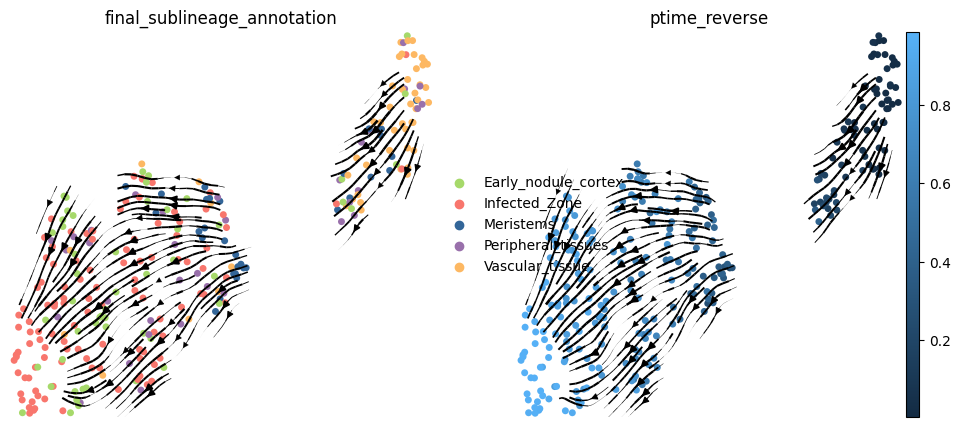

In [35]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 5))
grid_density = 0.97 # Default = 1, this is only used for proper visualization
sct.vf.plot_vector_field(adata2, zs_key='X_TNODE', vf_key='X_VF', use_rep_neigh='X_TNODE', color='final_sublineage_annotation', ax=axs[0],
                         reverse=True, show=False, legend_loc='right margin', frameon=False, size=100, alpha=1, palette=color_map)
sct.vf.plot_vector_field(adata2, zs_key='X_TNODE', vf_key='X_VF', use_rep_neigh='X_TNODE', color='ptime_reverse', ax=axs[1],
                         grid_density = grid_density, cmap=monocle2_pseudotime_cmap, 
                         reverse=True, show=False, legend_loc='right margin', frameon=False, size=100, alpha=1)
plt.savefig("scTOUR_Nodule_hvg2000_vector.svg")

In [25]:
adata.write_h5ad("scTOUR_Nodule_hvg1000.h5ad")
adata2.write_h5ad("scTOUR_Nodule_hvg2000.h5ad")